In [5]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
%config InlineBackend.figure_format = 'retina'

## Loading necessary Packages

In [6]:
%load_ext autoreload
%autoreload 2
from compatibility_tools import CompatibilityMeasure, ClusteringToolkit
from qutip import *
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Reprducting the results
> Measuring Incompatibility & Clustering Quantum Observables (PRL 130, 170201)

This notebook reproduces the paper's analytic incompatibility computations and example clustering of qubit observables using the helper class in `compatibility_tools.py`.


## Observables with no noise

### Legacy

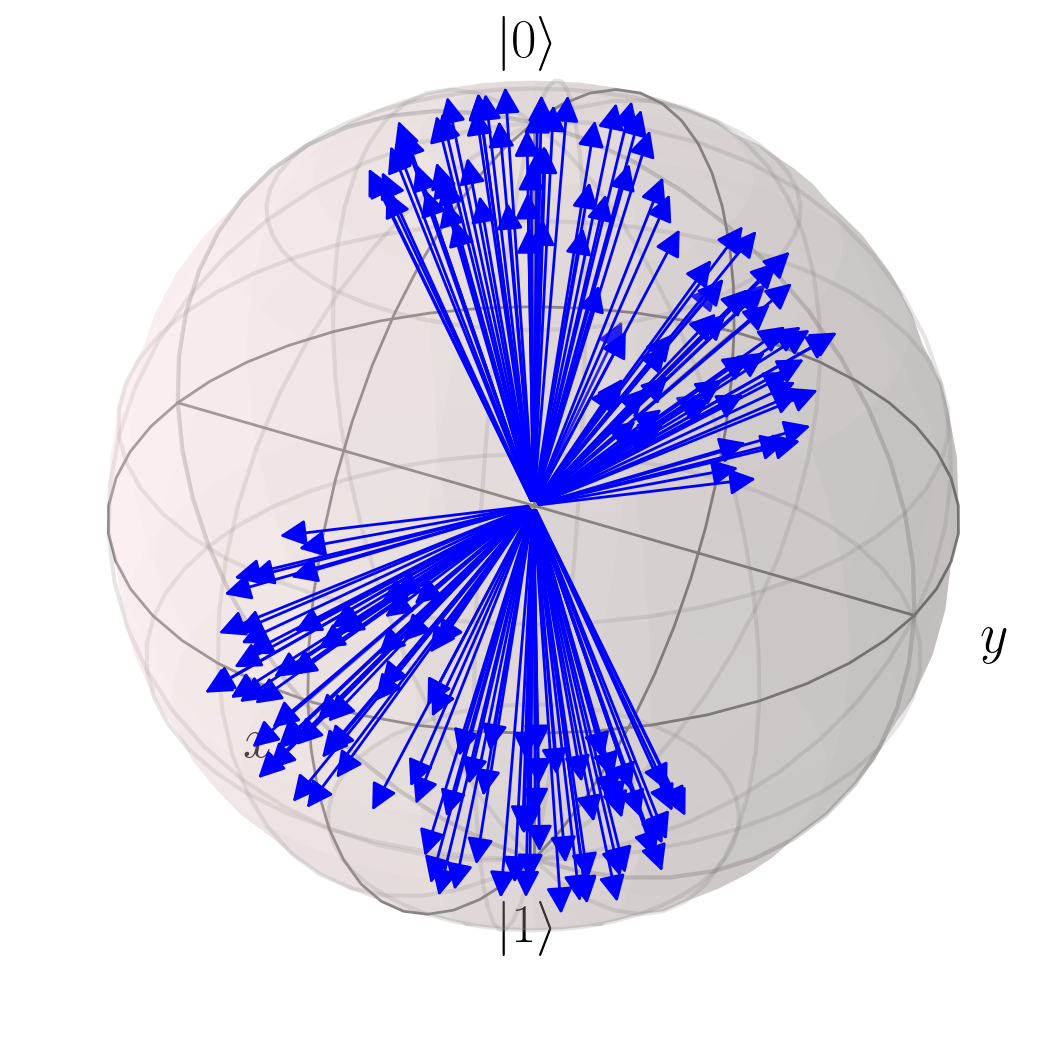

In [13]:
n = 100  # number of observables
vectors_around_x = cm.sample_unit_vectors_cone(n//2, theta_deg=22.5, axis=[1,0,0], rng=np.random.default_rng(42))
vectors_around_z = cm.sample_unit_vectors_cone(n//2, theta_deg=22.5, axis=[0,0,1], rng=np.random.default_rng(43))


# Normalize all vectors to unit length
vectors_around_x = vectors_around_x / np.linalg.norm(vectors_around_x, axis=1, keepdims=True)
vectors_around_z = vectors_around_z / np.linalg.norm(vectors_around_z, axis=1, keepdims=True)
all_vectors = np.vstack([vectors_around_x, vectors_around_z])

observables = [cm.projective_qubit_povm_from_axis(all_vectors[i]) for i in range(n)]

# Plot the axes of all observables on the Bloch sphere
b = Bloch()
b.vector_color = ['blue'] * (2*n)
b.vector_width = 1
for s in observables:
    b.add_states(s) #type: ignore
b.show()


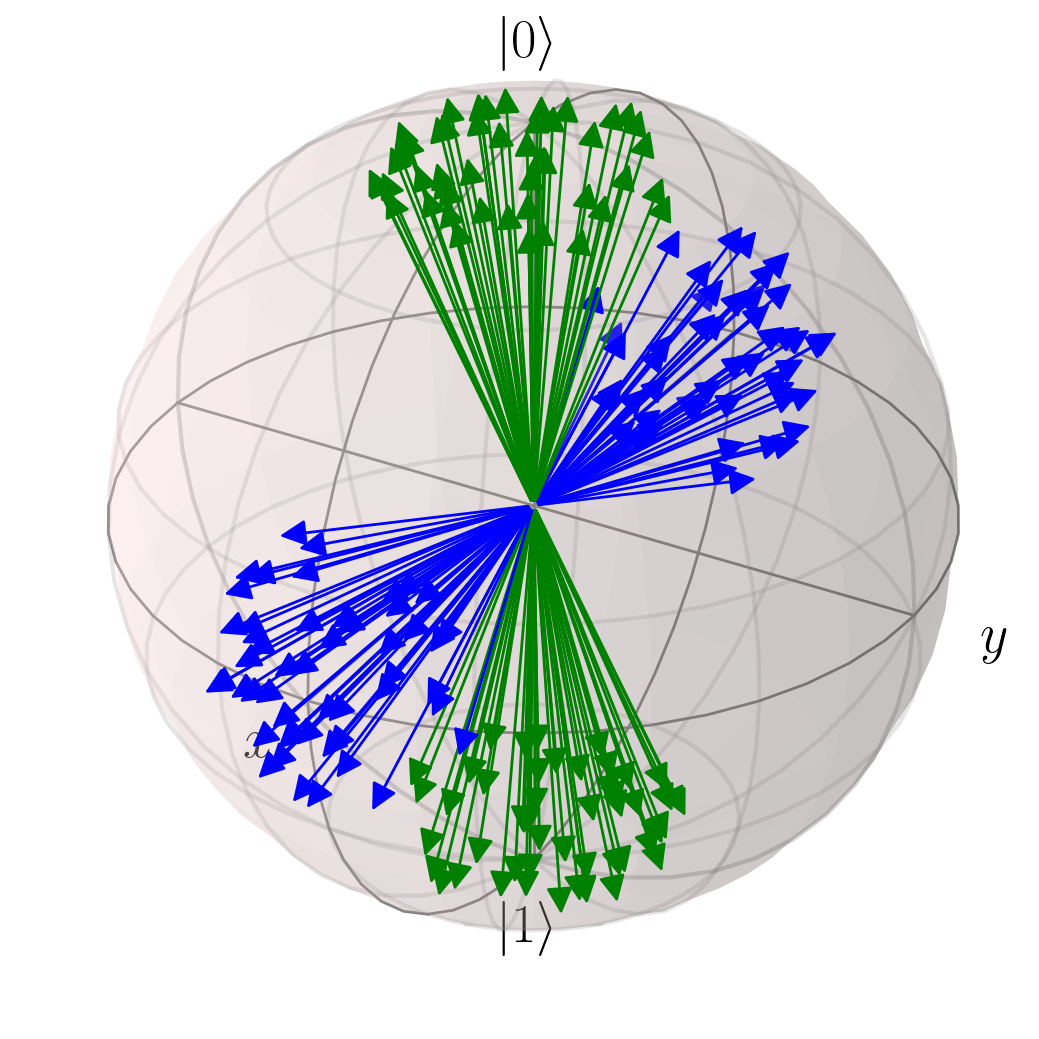

In [14]:
D = cm.incompatibility_distance_matrix(observables)

from compatibility_tools import ClusteringToolkit

labels = ct.cluster_from_distance(D, n_clusters=2, method='kmedoids')

# from sklearn_extra.cluster import KMedoids

# kmedoids = KMedoids(n_clusters=3, metric="precomputed", random_state=0)
# labels = kmedoids.fit_predict(D)

# Plot the axes of all observables on the Bloch sphere
b = Bloch()
b.vector_color = ['b' if labels[i//2]==0 else 'g' for i in range(2*n)]
b.vector_width = 1 
for s in observables:
    b.add_states(s)  # type: ignore
b.show()

os.makedirs("Plots&Data/MLQS", exist_ok=True)
b.fig.savefig("Plots&Data/MLQS/clustered_observables.png", dpi=300)

### New code

In [16]:
%load_ext autoreload
%autoreload 2
cm = CompatibilityMeasure(method = 'numerical')
spread_angle = 11.25
n_points_per_cluster = 50
ct = ClusteringToolkit(cm = cm, n_points = n_points_per_cluster, spread_angle = spread_angle, n_clusters = 2, mubs_array = [1, 1, 0], dimensions = 2)
dataset = ct.prepare_povm_dataset(noisy = False)
clustered_dataset = ct.cluster_povm_dataset(dataset)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[[0.         0.10559937 0.15718461 ... 0.70737205 0.69904015 0.69949951]
 [0.10559937 0.         0.10097258 ... 0.69772131 0.69704015 0.70014213]
 [0.15718461 0.10097258 0.         ... 0.69553181 0.67745367 0.69331317]
 ...
 [0.70737205 0.69772131 0.69553181 ... 0.         0.1500319  0.11804114]
 [0.69904015 0.69704015 0.67745367 ... 0.1500319  0.         0.14421817]
 [0.69949951 0.70014213 0.69331317 ... 0.11804114 0.14421817 0.        ]]


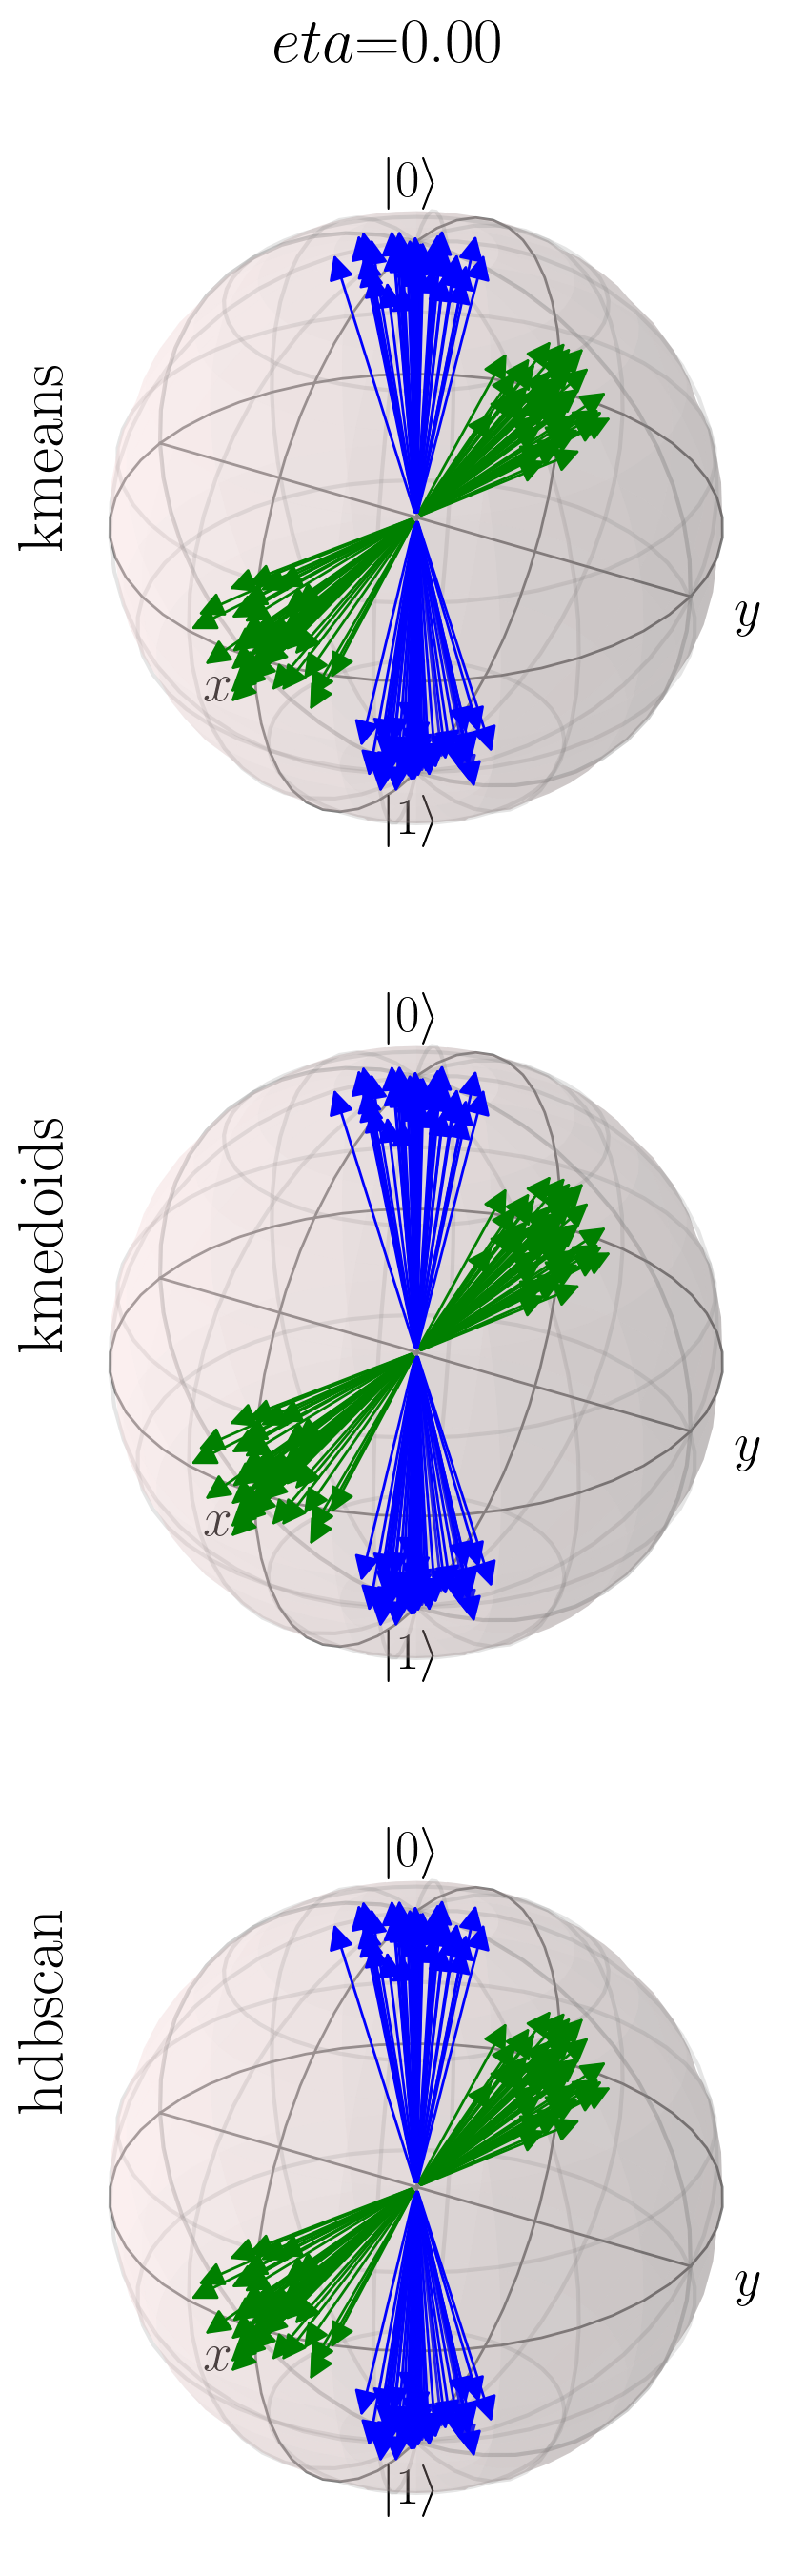

In [17]:
fontsize=24
# set global font sizes
plt.rcParams.update({
    "font.size": fontsize,
    "axes.titlesize": fontsize,
    "axes.labelsize": fontsize,
    "xtick.labelsize": int(fontsize * 0.9),
    "ytick.labelsize": int(fontsize * 0.9),
    "legend.fontsize": int(fontsize * 0.9),
})

# savepath=f"Plots&Data/MLQS/kmeans_kmedoids_comparison_[{spread_angle:.2f}_noiseless].png"
savepath = None
methods = ('kmeans','kmedoids', 'hdbscan')
ct.plot_eta_grid_from_dataset(dataset, methods=methods, savepath=savepath, fontsize=fontsize) 

## Noisy Observables

### Legacy

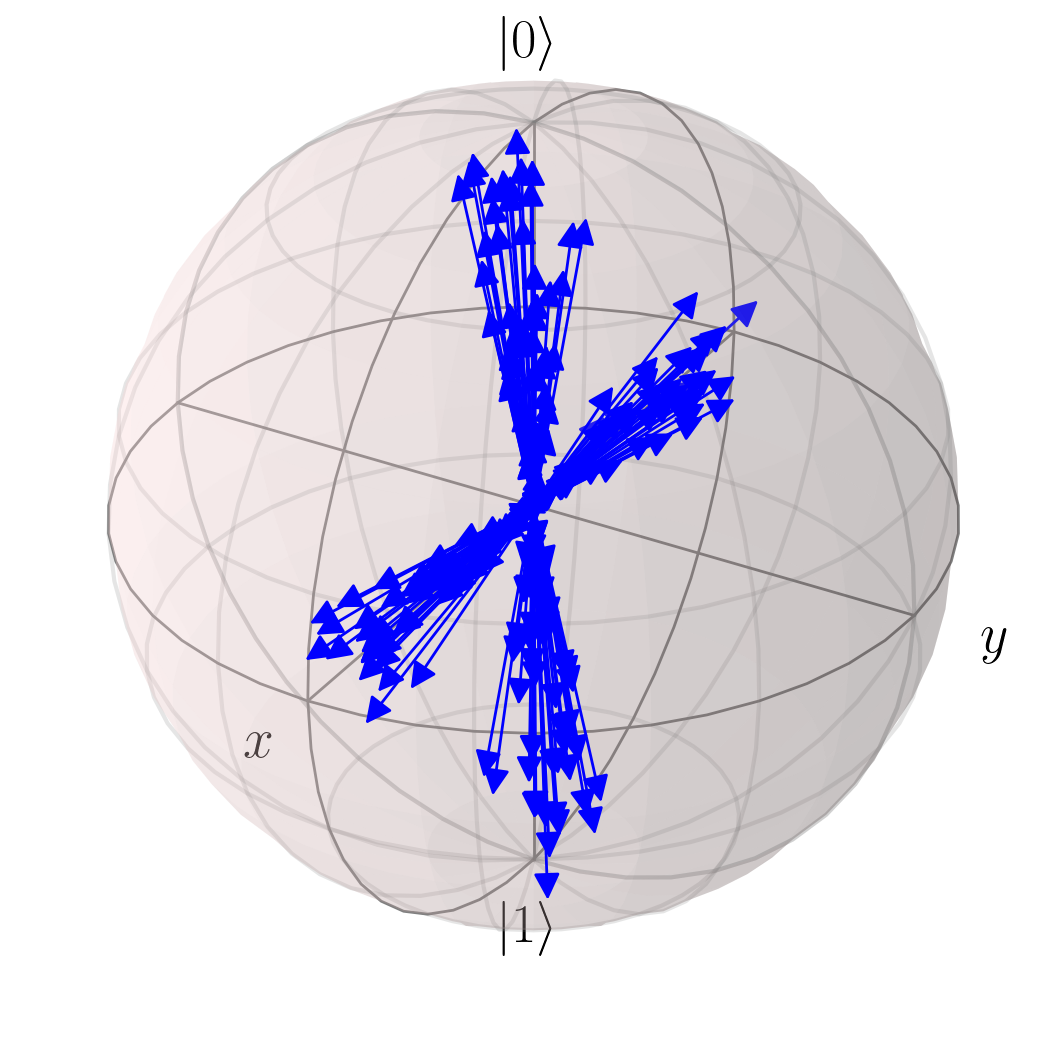

In [54]:
n = 100  # number of observables
spread_angle = 22.5/2  # degrees
vectors_around_x = cm.sample_unit_vectors_cone(n//2, theta_deg=spread_angle, axis=[1,0,0], rng=np.random.default_rng(42))
vectors_around_z = cm.sample_unit_vectors_cone(n//2, theta_deg=spread_angle, axis=[0,0,1], rng=np.random.default_rng(43))

# Normalize all vectors to unit length
vectors_around_x = vectors_around_x / np.linalg.norm(vectors_around_x, axis=1, keepdims=True)
vectors_around_z = vectors_around_z / np.linalg.norm(vectors_around_z, axis=1, keepdims=True)
all_vectors = np.vstack([vectors_around_x, vectors_around_z])

observables = [cm.projective_qubit_povm_from_axis(all_vectors[i]) for i in range(n)]

# Add noise to the observables
max_noise_eta = 0.90
rng = np.random.default_rng(None)
# Sample base_Rl including both endpoints [0, 1]
base_Rl = rng.uniform(low=0, high=1, size=n)
# base_Rl[-1] = 1.0  # explicitly set the last value to the high endpoint
lam = max_noise_eta * base_Rl
noisy_observables, noisy_kraus_ops = [], []
for i, obs in enumerate(observables):
    noisy_obs, noisy_kraus = cm.noisy_povm_with_kraus_qobj(obs, lam=lam[i])
    noisy_observables.append(noisy_obs)
    noisy_kraus_ops.append(noisy_kraus)

# Plot the axes of all observables on the Bloch sphere
b = Bloch()
b.vector_color = ['blue'] * (2*n)
b.vector_width = 1
for s in noisy_observables:
    b.add_states(s) #type: ignore
b.show()


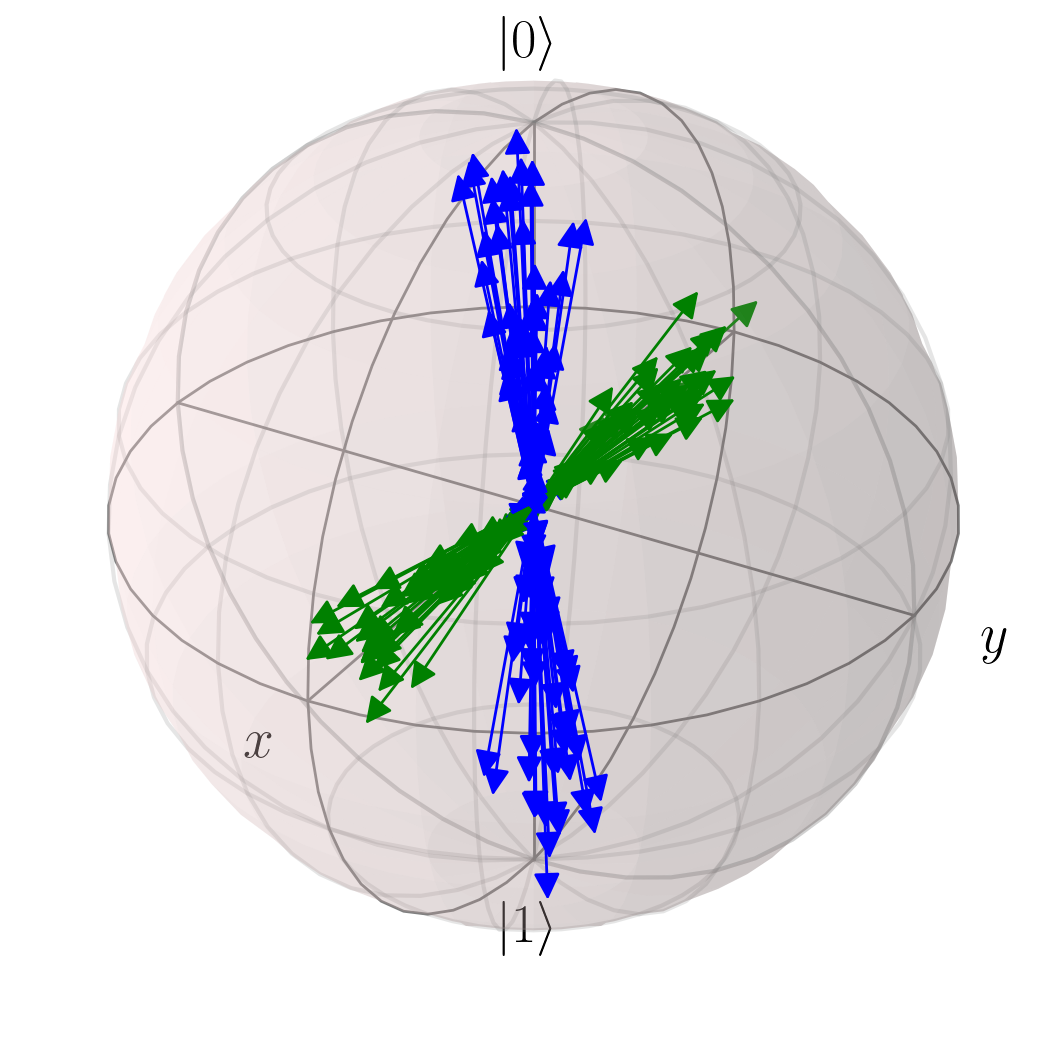

In [56]:
noisy_kraus_ops_flat = [[k for krauses in obs for k in krauses] for obs in noisy_kraus_ops]
D = cm.incompatibility_distance_matrix(noisy_kraus_ops_flat)

from compatibility_tools import ClusteringToolkit

method = 'kmedoids'
method = 'kmeans'

labels = ct.cluster_from_distance(D, n_clusters=2, method=method)

# from sklearn_extra.cluster import KMedoids

# kmedoids = KMedoids(n_clusters=3, metric="precomputed", random_state=0)
# labels = kmedoids.fit_predict(D)

# Plot the axes of all observables on the Bloch sphere
b = Bloch()
b.vector_color = ['b' if labels[i//2]==0 else 'g' for i in range(2*n)]
b.vector_width = 1 
for s in noisy_observables:
    b.add_states(s)  # type: ignore
b.show()

os.makedirs("Plots&Data/MLQS", exist_ok=True)
b.fig.savefig(f"Plots&Data/MLQS/{method}_clustered_noisy_observables_[{spread_angle:.2f}][{max_noise_eta:.2f}].png", dpi=300)

### Comparison (New code)

In [21]:
%reload_ext autoreload
cm = CompatibilityMeasure(method = 'analytical')
spread_angle = 11.25
n_points_per_cluster = 50
ct = ClusteringToolkit(cm = cm, n_points = n_points_per_cluster, spread_angle = spread_angle, n_clusters = 2, mubs_array = [1, 1, 0], dimensions = 2)
etas = [0.25, 0.50, 0.75]
dataset = ct.prepare_povm_dataset(noisy = True, etas = etas)
clustered_dataset = ct.cluster_povm_dataset(dataset, methods=('kmeans','kmedoids','hdbscan'))
# ct.save_noisy_dataset(dataset)  # optional

[[0.         0.70915258 0.70898613 ... 0.75038494 0.79887662 0.77003648]
 [0.70915258 0.         0.70712095 ... 0.74347834 0.79195738 0.76525331]
 [0.70898613 0.70712095 0.         ... 0.73192036 0.76625513 0.74742978]
 ...
 [0.75038494 0.74347834 0.73192036 ... 0.         0.70886919 0.70850239]
 [0.79887662 0.79195738 0.76625513 ... 0.70886919 0.         0.70716223]
 [0.77003648 0.76525331 0.74742978 ... 0.70850239 0.70716223 0.        ]]
[[0.         0.7083617  0.70781692 ... 0.72451698 0.77677036 0.74583713]
 [0.7083617  0.         0.70710698 ... 0.72125074 0.77245718 0.74343816]
 [0.70781692 0.70710698 0.         ... 0.71304696 0.7354706  0.72270299]
 ...
 [0.72451698 0.72125074 0.71304696 ... 0.         0.70766497 0.7075118 ]
 [0.77677036 0.77245718 0.7354706  ... 0.70766497 0.         0.70714382]
 [0.74583713 0.74343816 0.72270299 ... 0.7075118  0.70714382 0.        ]]
[[0.         0.70769138 0.70724376 ... 0.71145881 0.75977023 0.72830303]
 [0.70769138 0.         0.70709902 ... 

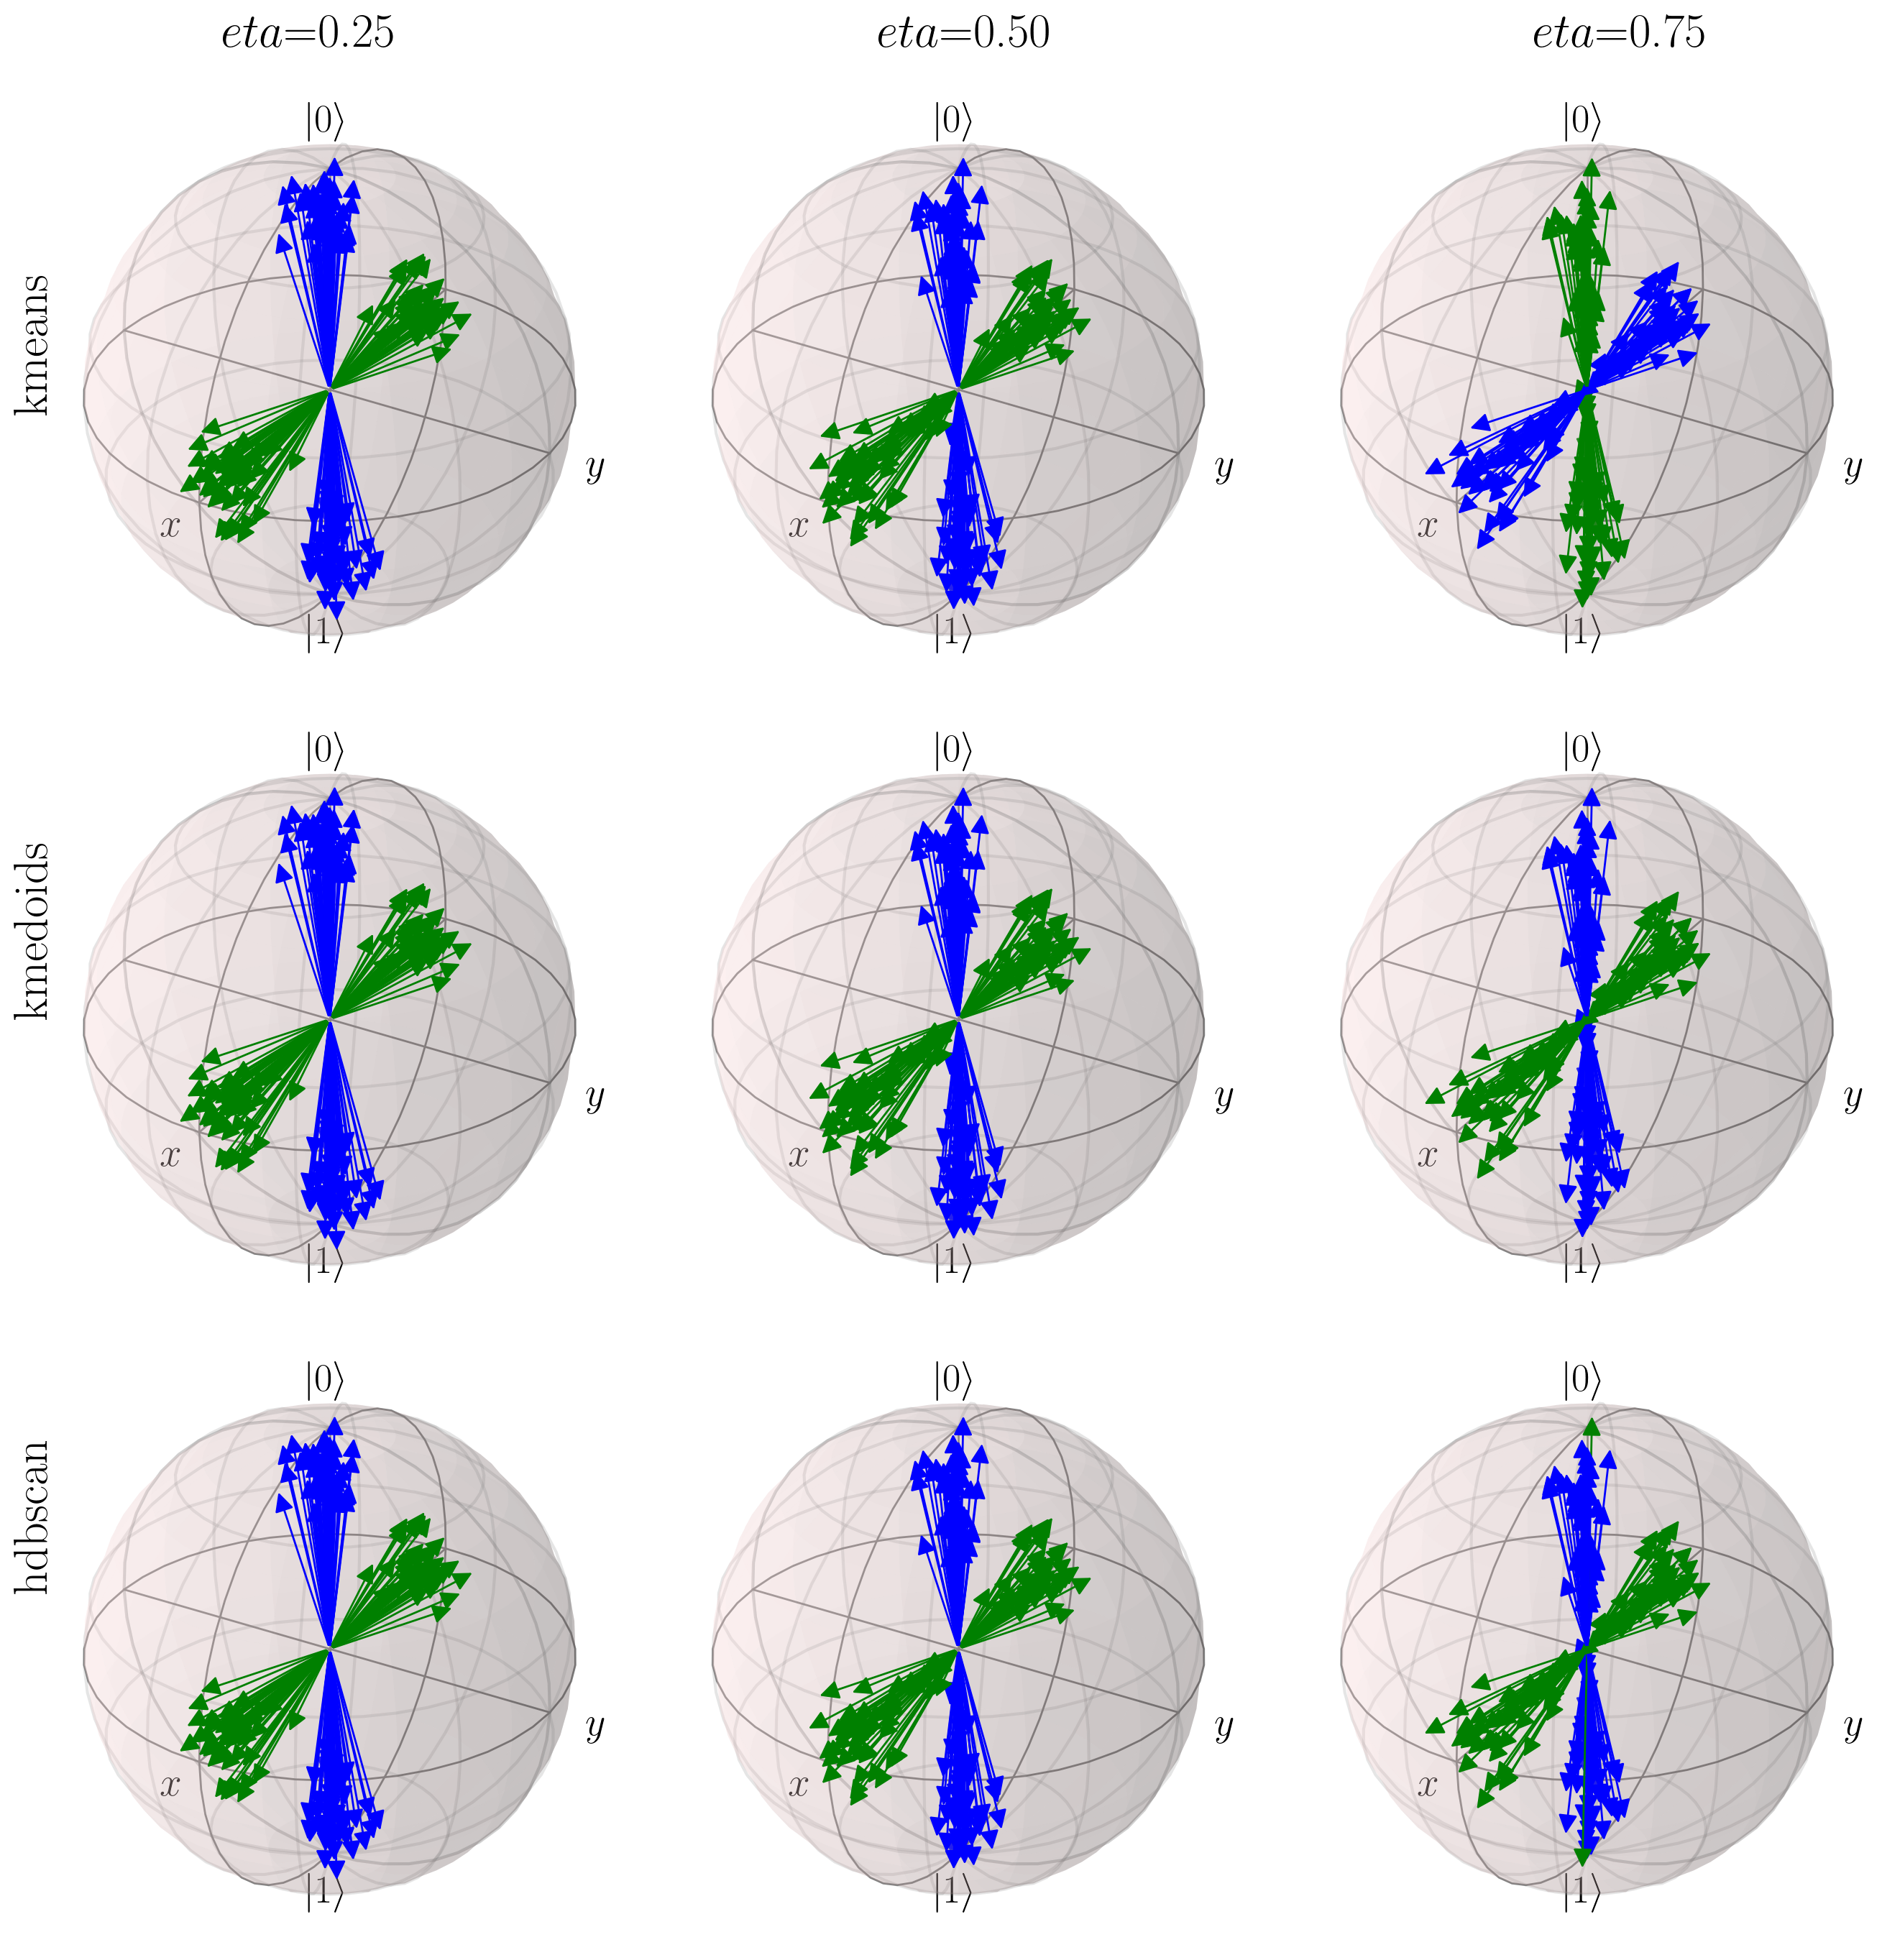

In [22]:
# %reload_ext autoreload
fontsize=24
# set global font sizes
plt.rcParams.update({
    "font.size": fontsize,
    "axes.titlesize": fontsize,
    "axes.labelsize": fontsize,
    "xtick.labelsize": int(fontsize * 0.9),
    "ytick.labelsize": int(fontsize * 0.9),
    "legend.fontsize": int(fontsize * 0.9),
})

savepath=f"Plots&Data/MLQS/kmeans_kmedoids_comparison_[{spread_angle:.2f}].png"
savepath = None
methods = ('kmeans','kmedoids', 'hdbscan')
ct.plot_eta_grid_from_dataset(dataset, methods=methods, savepath=savepath, fontsize=fontsize) 

# Increasing the Number of Clusters

## Without Noise

In [21]:
%load_ext autoreload
%autoreload 2
cm = CompatibilityMeasure(method = 'analytical')
spread_angle = 11.25
n_points_per_cluster = 100
ct = ClusteringToolkit(cm = cm, n_points = n_points_per_cluster, spread_angle = spread_angle, n_clusters = 3, mubs_array = [1, 1, 1], dimensions = 2)
dataset = ct.prepare_povm_dataset(noisy = False)
clustered_dataset = ct.cluster_povm_dataset(dataset)

d:\UniVie\Projects\MLQuantumSwitch\Code\compatibility_tools.py:974: SyntaxWarning: invalid escape sequence '\%'
  if annotate:


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


d:\UniVie\Projects\MLQuantumSwitch\Code\compatibility_tools.py:974: SyntaxWarning: invalid escape sequence '\%'
  if annotate:


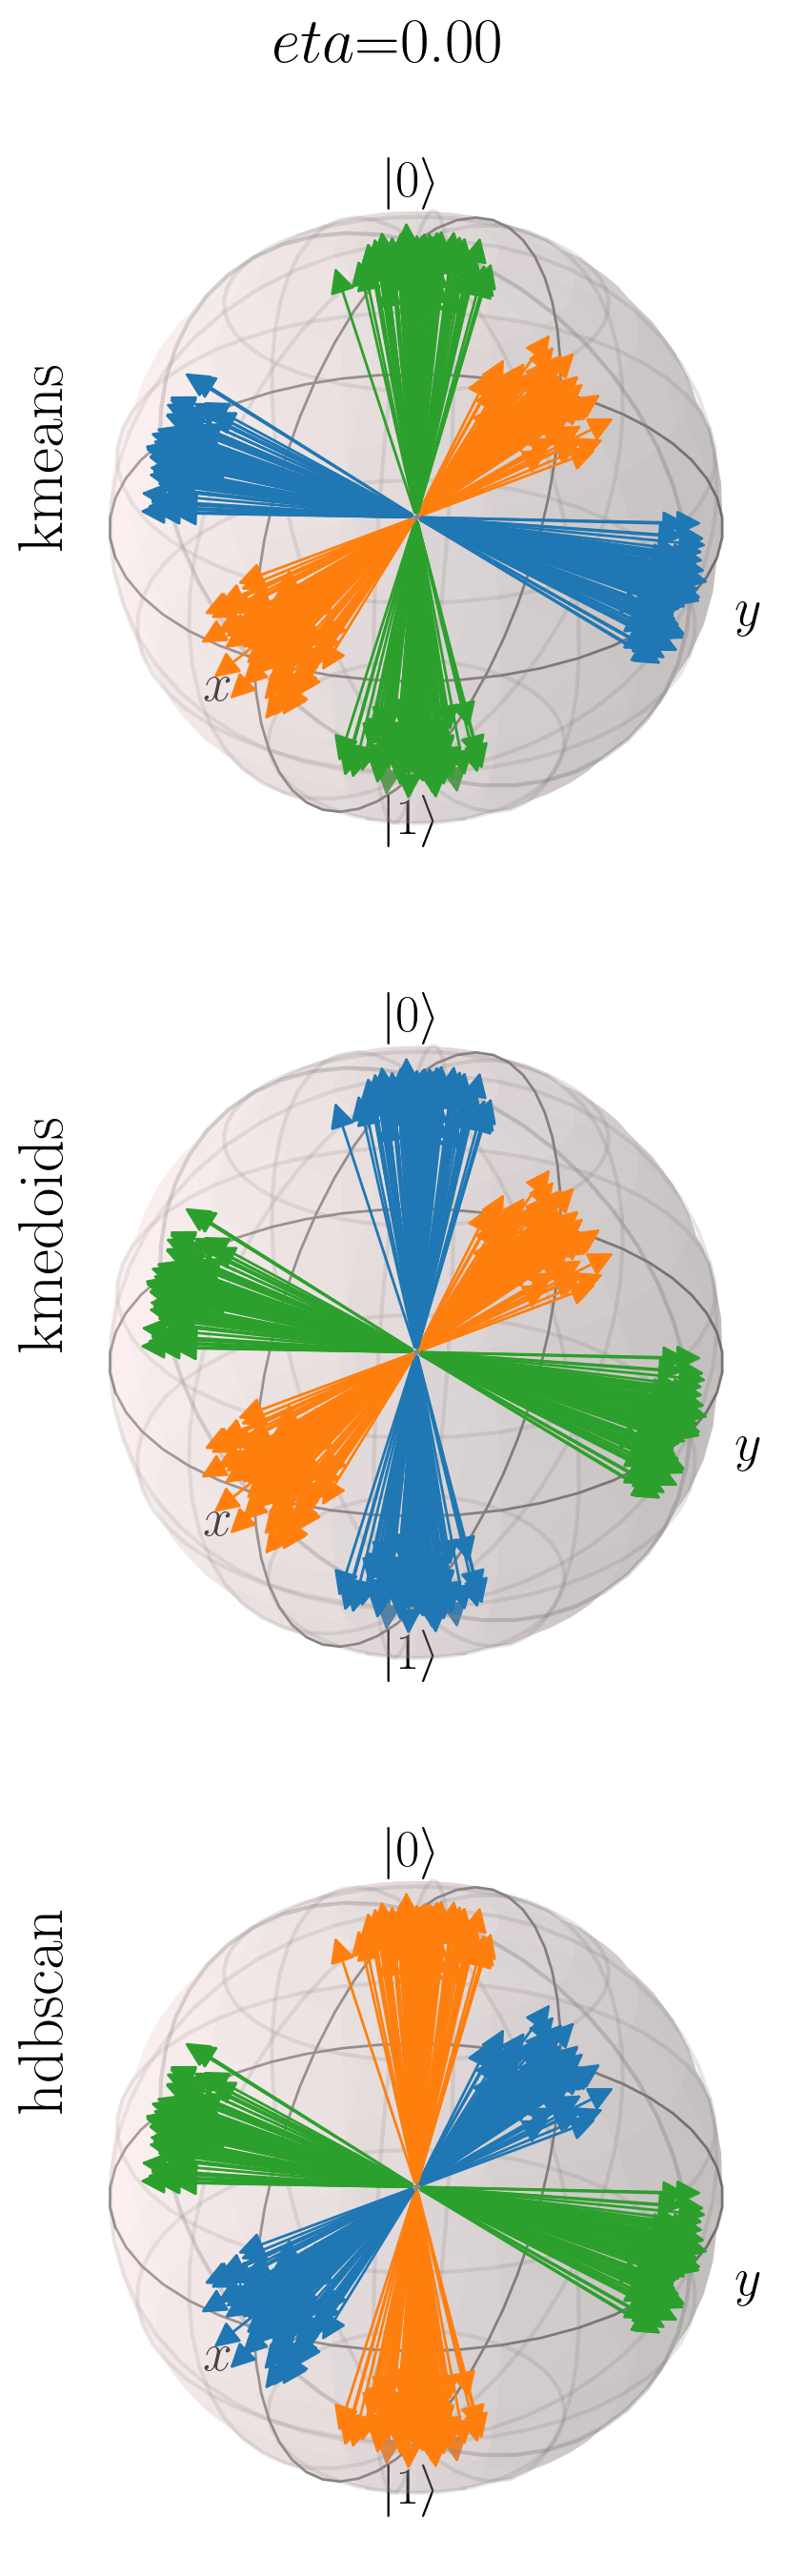

In [ ]:
%reload_ext autoreload
%autoreload 2
fontsize=24
# set global font sizes
plt.rcParams.update({
    "font.size": fontsize,
    "axes.titlesize": fontsize,
    "axes.labelsize": fontsize,
    "xtick.labelsize": int(fontsize * 0.9),
    "ytick.labelsize": int(fontsize * 0.9),
    "legend.fontsize": int(fontsize * 0.9),
})

savepath=f"Plots&Data/MLQS/kmeans_kmedoids_comparison_[{spread_angle:.2f}].png"
savepath = None
methods = ('kmeans','kmedoids', 'hdbscan')
ct.plot_eta_grid_from_dataset(dataset = clustered_dataset, methods=methods, savepath=savepath, fontsize=fontsize) 

## With Noise

In [ ]:
%reload_ext autoreload
%autoreload 2
cm = CompatibilityMeasure(method = 'numerical')
spread_angle = 11.25
n_points_per_cluster = 100
ct = ClusteringToolkit(cm = cm, n_points = n_points_per_cluster, spread_angle = spread_angle, n_clusters = 3, mubs_array = [1, 1, 1], dimensions = 2)
etas = [0.25, 0.50, 0.75]
dataset = ct.prepare_povm_dataset(noisy = True, etas = etas)
clustered_dataset = ct.cluster_povm_dataset(dataset)

d:\UniVie\Projects\MLQuantumSwitch\Code\compatibility_tools.py:398: UserWarning: [NCOM] Overlap out of [0,1]: 1.00359. Clipping to [0,1].
  warnings.warn(f"[NCOM] Overlap out of [0,1]: {overlap:.6g}. Clipping to [0,1].")
d:\UniVie\Projects\MLQuantumSwitch\Code\compatibility_tools.py:398: UserWarning: [NCOM] Overlap out of [0,1]: 1.00015. Clipping to [0,1].
  warnings.warn(f"[NCOM] Overlap out of [0,1]: {overlap:.6g}. Clipping to [0,1].")
d:\UniVie\Projects\MLQuantumSwitch\Code\compatibility_tools.py:398: UserWarning: [NCOM] Overlap out of [0,1]: 1.00163. Clipping to [0,1].
  warnings.warn(f"[NCOM] Overlap out of [0,1]: {overlap:.6g}. Clipping to [0,1].")
d:\UniVie\Projects\MLQuantumSwitch\Code\compatibility_tools.py:398: UserWarning: [NCOM] Overlap out of [0,1]: 1.00037. Clipping to [0,1].
  warnings.warn(f"[NCOM] Overlap out of [0,1]: {overlap:.6g}. Clipping to [0,1].")
d:\UniVie\Projects\MLQuantumSwitch\Code\compatibility_tools.py:398: UserWarning: [NCOM] Overlap out of [0,1]: 1.0008

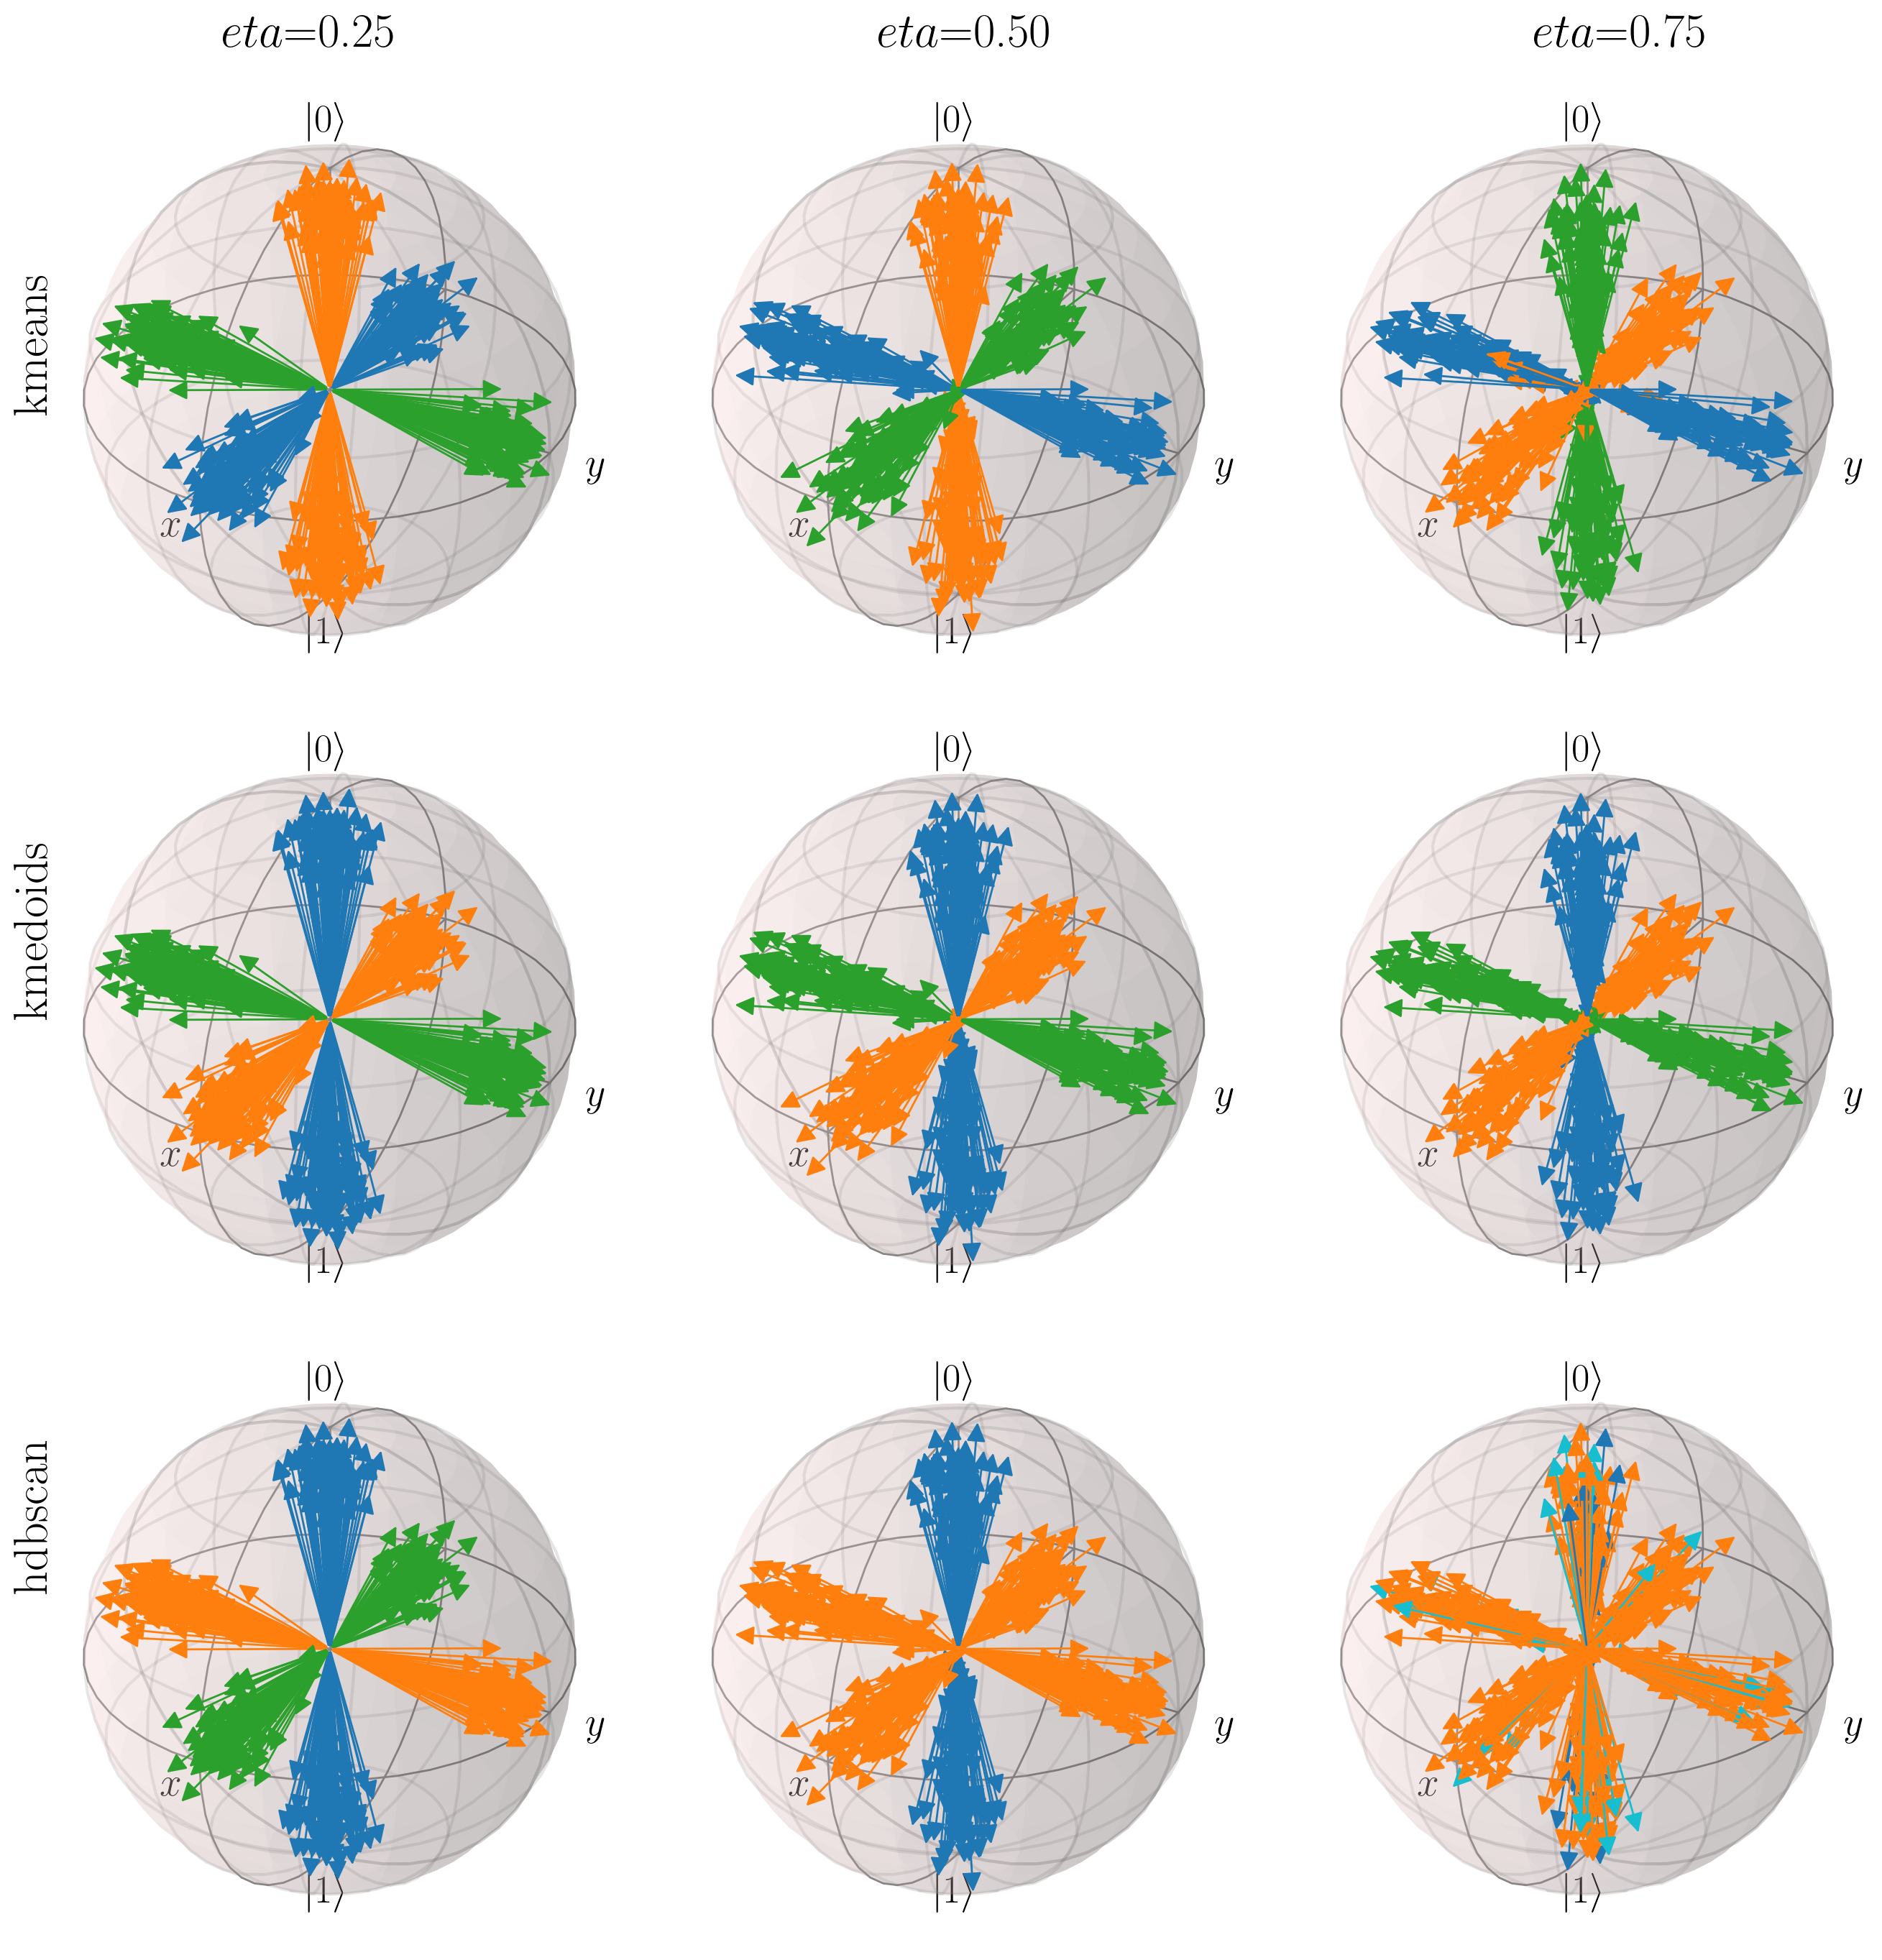

In [19]:
%reload_ext autoreload
%autoreload 2
os.makedirs("Plots&Data/MLQS/3dims", exist_ok=True)
ct.save_dataset(clustered_dataset, path_npz="Plots&Data/MLQS/noisy_clustered_dataset.npz", path_pkl="Plots&Data/MLQS/noisy_clustered_dataset.pkl")
fontsize=24
# set global font sizes
plt.rcParams.update({
    "font.size": fontsize,
    "axes.titlesize": fontsize,
    "axes.labelsize": fontsize,
    "xtick.labelsize": int(fontsize * 0.9),
    "ytick.labelsize": int(fontsize * 0.9),
    "legend.fontsize": int(fontsize * 0.9),
})

# savepath=f"Plots&Data/MLQS/kmeans_kmedoids_comparison_[{spread_angle:.2f}_3clusters].png"
savepath = None
methods = ('kmeans','kmedoids', 'hdbscan')
ct.plot_eta_grid_from_dataset(dataset = clustered_dataset, methods=methods, savepath=savepath, fontsize=fontsize) 

# Extending the Method to Higher Dimensions

## Without noise

In [ ]:
%load_ext autoreload
%autoreload 2
cm = CompatibilityMeasure(method = 'analytical')
spread_angle = 11.25
n_points_per_cluster = 100
ct = ClusteringToolkit(cm = cm, n_points = n_points_per_cluster, spread_angle = spread_angle, n_clusters = 4, mubs_array = [1, 1, 1, 1], dimensions = 3)
dataset = ct.prepare_povm_dataset(noisy = False)
clustered_dataset = ct.cluster_povm_dataset(dataset)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


{0.0: array([100., 100., 100., 100.])}

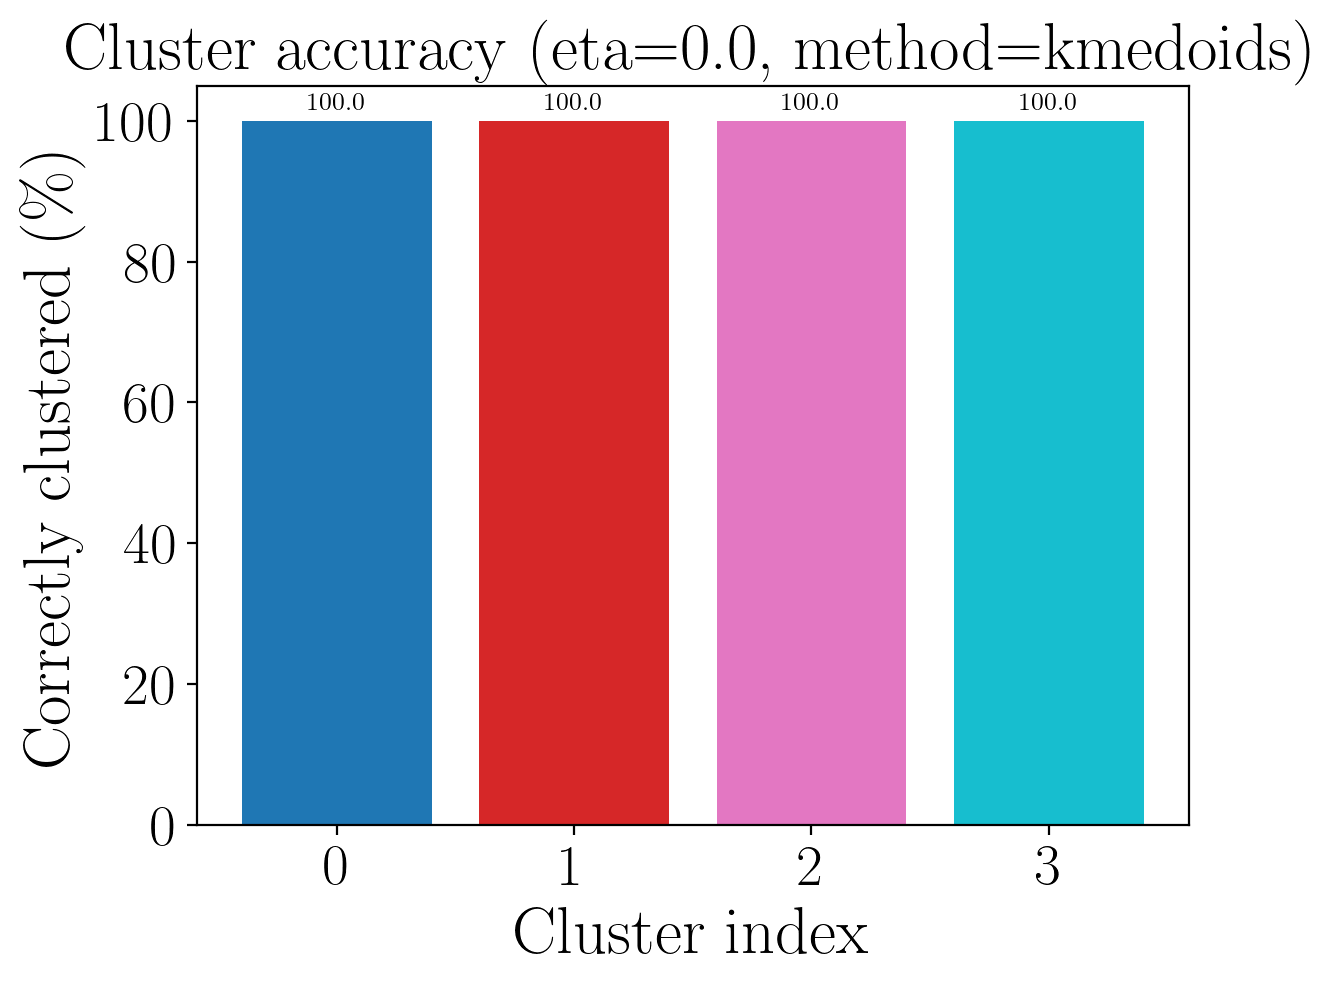

In [25]:
%reload_ext autoreload
%autoreload 2
fontsize=24
# set global font sizes
plt.rcParams.update({
    "font.size": fontsize,
    "axes.titlesize": fontsize,
    "axes.labelsize": fontsize,
    "xtick.labelsize": int(fontsize * 0.9),
    "ytick.labelsize": int(fontsize * 0.9),
    "legend.fontsize": int(fontsize * 0.9),
})

# savepath=f"Plots&Data/MLQS/kmeans_kmedoids_comparison_[{spread_angle:.2f}_noiseless].png"
savepath = None
methods = ('kmeans','kmedoids', 'hdbscan')
ct.plot_cluster_accuracy_hist(clustered_dataset)

## With noise

In [36]:
%load_ext autoreload
%autoreload 2
cm = CompatibilityMeasure(method = 'analytical')
spread_angle = 11.25
n_points_per_cluster = 100
ct = ClusteringToolkit(cm = cm, n_points = n_points_per_cluster, spread_angle = spread_angle, n_clusters = 4, mubs_array = [1, 1, 1, 1], dimensions = 3, splits=1)
etas = [0.25, 0.50, 0.75]
dataset = ct.prepare_povm_dataset(noisy = True, etas = etas)
clustered_dataset = ct.cluster_povm_dataset(dataset)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


{0.25: array([100., 100., 100., 100.]),
 0.5: array([100., 100., 100., 100.]),
 0.75: array([100., 100., 100., 100.])}

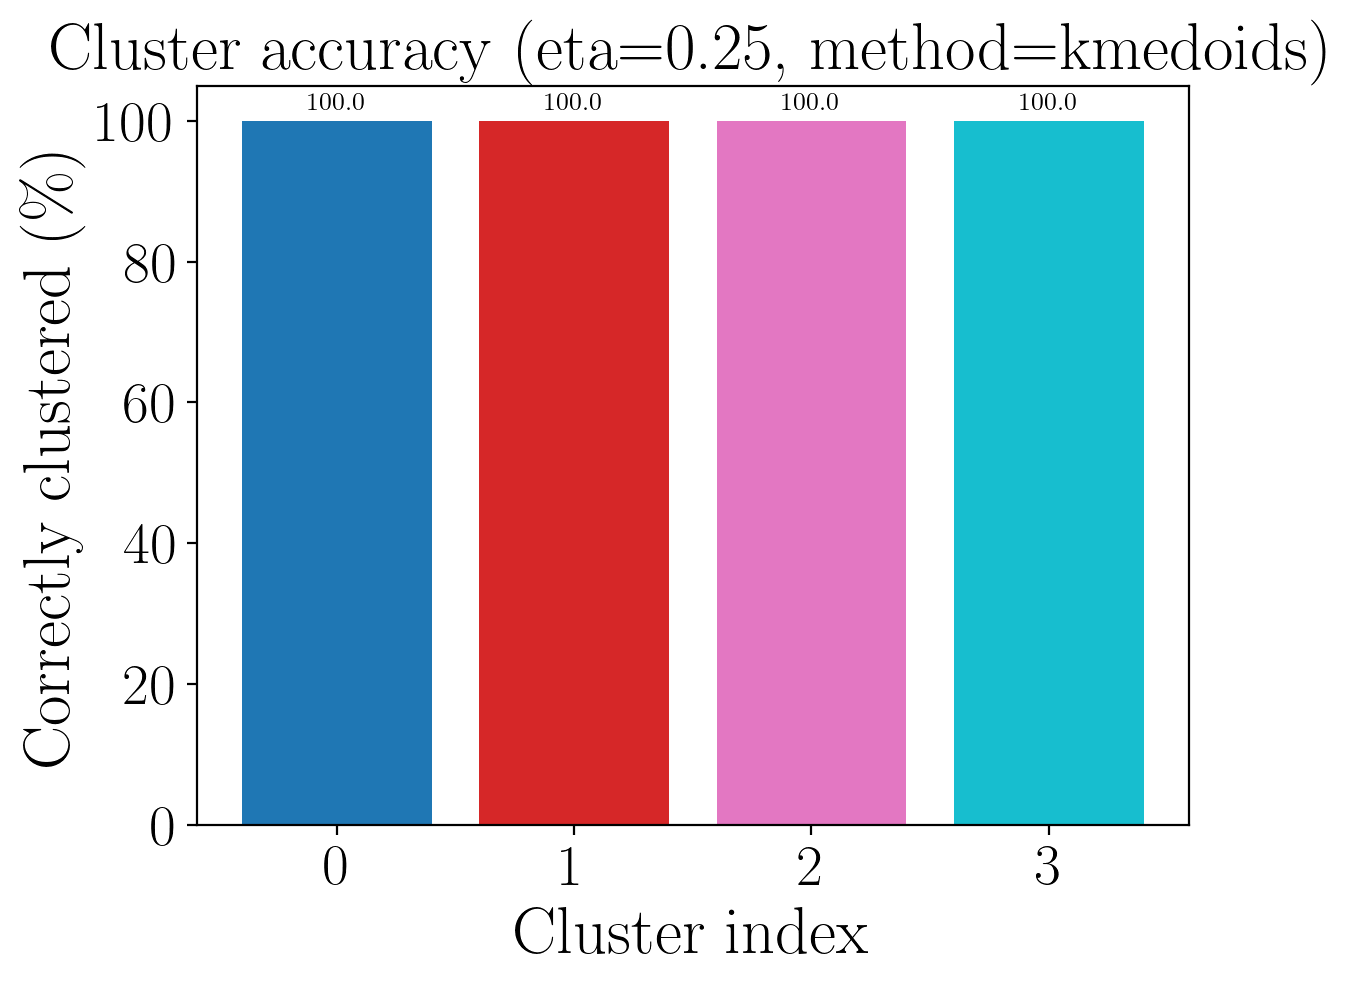

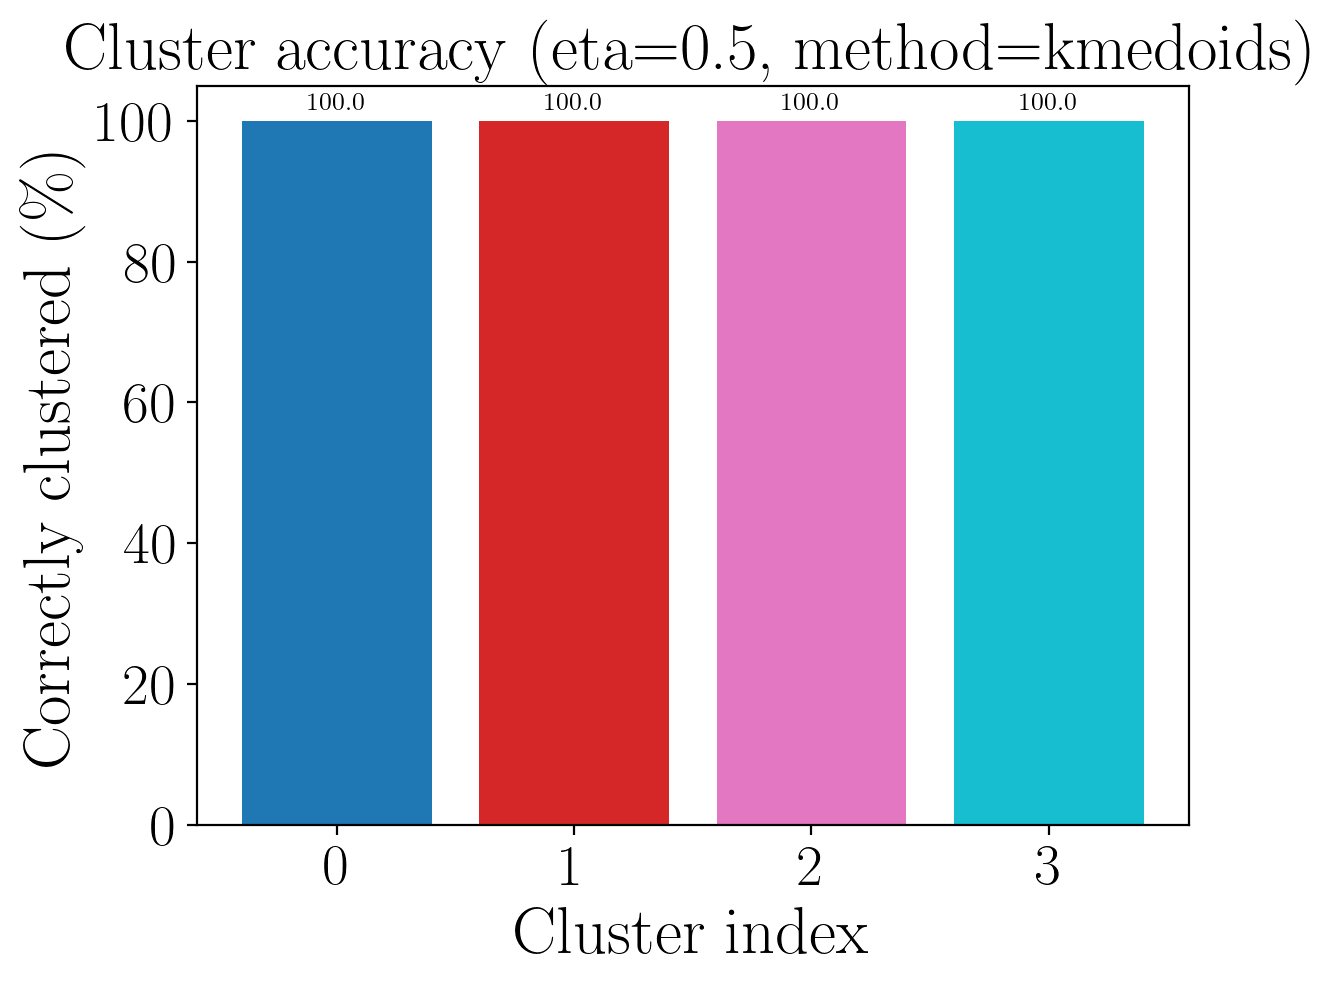

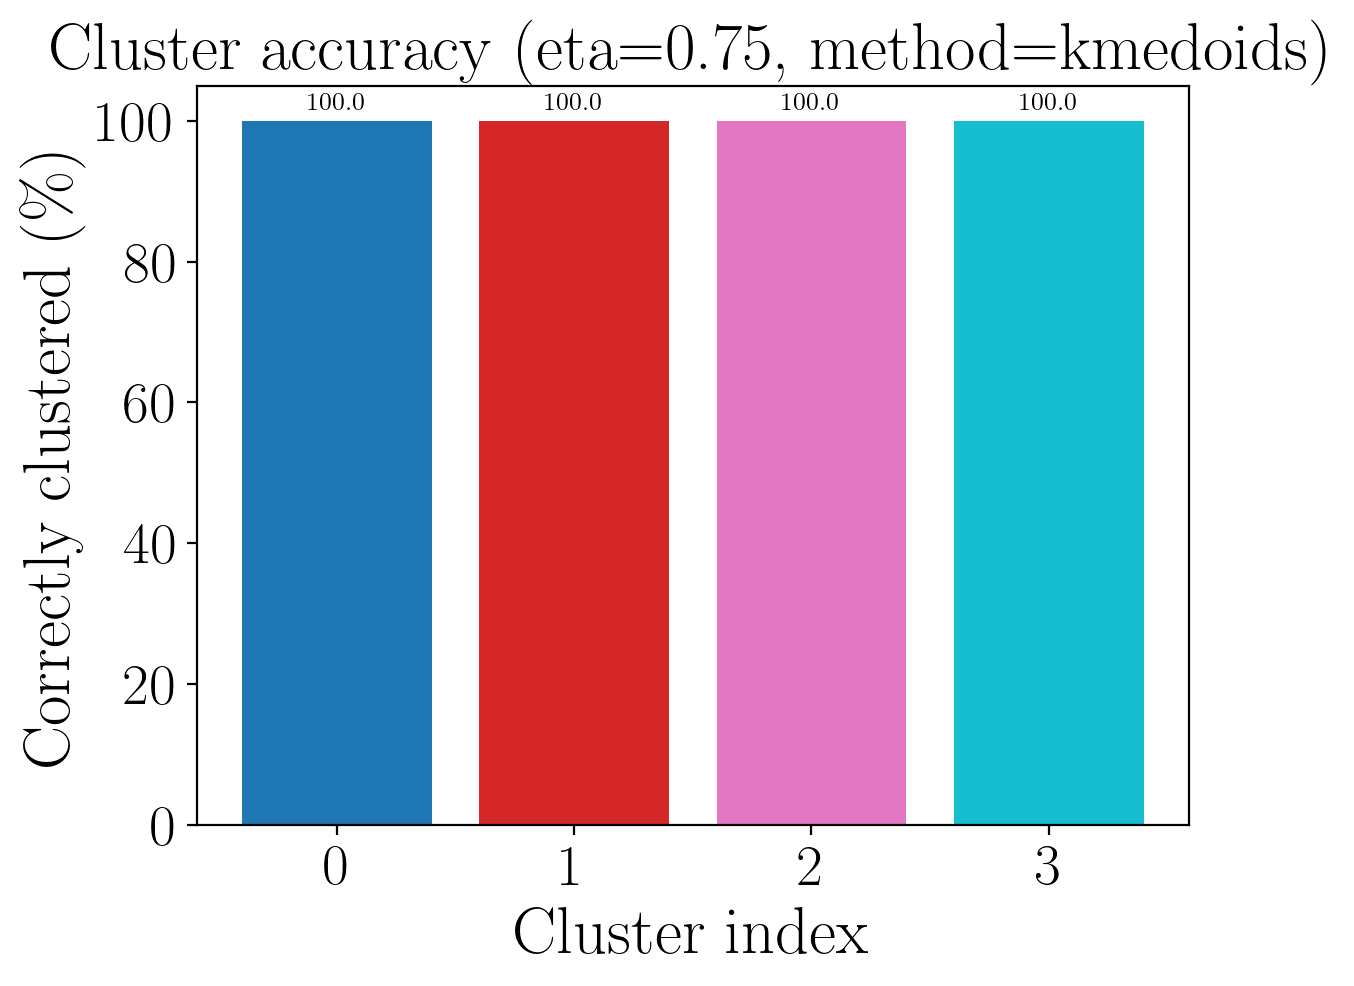

In [39]:
%reload_ext autoreload
%autoreload 2
os.makedirs("Plots&Data/MLQS/3dims", exist_ok=True)
ct.save_dataset(clustered_dataset, path_npz="Plots&Data/MLQS/3dims/noisy_clustered_dataset.npz", path_pkl="Plots&Data/MLQS/3dims/noisy_clustered_dataset.pkl")
fontsize=24
# set global font sizes
plt.rcParams.update({
    "font.size": fontsize,
    "axes.titlesize": fontsize,
    "axes.labelsize": fontsize,
    "xtick.labelsize": int(fontsize * 0.9),
    "ytick.labelsize": int(fontsize * 0.9),
    "legend.fontsize": int(fontsize * 0.9),
})

savepath=f"Plots&Data/MLQS/3dims/cluster_accuracy_hist.png"
# savepath = None
methods = ('kmeans','kmedoids', 'hdbscan')
ct.plot_cluster_accuracy_hist(clustered_dataset, savepath=savepath)

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

In [ ]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, random_state=2025, n_classes=2, n_clusters_per_class=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

gram_matrix = np.zeros((len(X_train), len(X_train)))
for i in range(len(X_train)):
    for j in range(len(X_train)):
        # Some encoding from X to Operators 
        gram_matrix[i, j] = # Compatibilitz Measure between X_train[i] and X_train[j]

svc = SVC(kernel='precomputed')
svc.fit(gram_matrix, y_train)
# Predict on the test set
test_gram_matrix = np.zeros((len(X_test), len(X_train)))
for i in range(len(X_test)):
    for j in range(len(X_train)):
        # Some encoding from X to Operators 
        test_gram_matrix[i, j] = # Compatibilitz Measure between X_test[i] and X_train[j]

y_pred = svc.predict(test_gram_matrix)
# Evaluate the accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Test set accuracy: {accuracy * 100:.2f}%")

In [14]:
a = sigmaz()
b = a.conj()
print(a)
print(b+a)

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 1.  0.]
 [ 0. -1.]]
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 2.  0.]
 [ 0. -2.]]
